# 01 — EDA and Preprocessing Notebook

This notebook mirrors the **Import Data** and **Preprocessing** pages. It loads the yearly panel dataset, checks quality, visualizes distributions, handles missing values/outliers, scales features, and creates the final country-level dataset used by clustering/PCA/anomaly notebooks.

In [13]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook paths: this assumes the notebooks folder is copied into your project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATHS = [
    PROJECT_ROOT / "sample_datasets" / "world_panel_2010_2023.csv",
    PROJECT_ROOT / "data" / "raw" / "world_panel_2010_2023.csv",
    Path("/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find world_panel_2010_2023.csv. Put this notebook folder in the project root.")

CHARTS_DIR = PROJECT_ROOT / "charts" / Path.cwd().name.replace(" ", "_")
if Path.cwd().name != "notebooks":
    # when executed from project root, use the notebook-specific folder manually below
    CHARTS_DIR = PROJECT_ROOT / "charts" / "01_preprocessing_eda"
PROCESSED_DIR = PROJECT_ROOT / "after_processing_dataset"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(name, dpi=160):
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart: {path}")
    plt.show()

def save_df(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved dataset: {path}")
    return path

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv
Shape: (336, 22)


,country,code,region,year,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,2010,4228.1,0.4909,72.14,87.32,25.38,1.185,...,5.521,8.038,50.25,0.1510,53.42,14.99,39.19,67.62,553.0,260960120
1,Algeria,DZA,Africa,2011,4374.9,0.4849,72.37,86.10,34.32,1.176,...,5.321,7.755,52.43,0.2402,53.22,10.16,37.60,68.63,551.4,268501465
2,Algeria,DZA,Africa,2012,4500.8,0.4914,72.45,87.41,33.08,1.145,...,5.152,7.301,44.42,-0.0675,52.50,14.07,43.97,67.39,554.0,276758265
3,Algeria,DZA,Africa,2013,4649.6,0.4930,72.46,87.03,31.79,1.453,...,5.712,7.988,50.39,0.0478,54.45,11.86,43.34,68.68,522.7,285130821
4,Algeria,DZA,Africa,2014,4744.8,0.4983,72.98,89.22,34.49,1.174,...,5.411,8.000,46.90,0.1721,53.59,11.30,43.23,67.58,524.3,292485149


## 1. Dataset structure

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 336 non-null    str    
 1   code                    336 non-null    str    
 2   region                  336 non-null    str    
 3   year                    336 non-null    int64  
 4   gdp_per_capita          336 non-null    float64
 5   hdi                     336 non-null    float64
 6   life_expectancy         336 non-null    float64
 7   literacy_rate           336 non-null    float64
 8   internet_usage_pct      336 non-null    float64
 9   co2_per_capita          336 non-null    float64
 10  fertility_rate          336 non-null    float64
 11  infant_mortality        336 non-null    float64
 12  education_spending_pct  336 non-null    float64
 13  health_spending_pct     336 non-null    float64
 14  gini_index              336 non-null    float64
 15  

In [15]:
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
year,336.0,2.016500e+03,4.037000e+00,2.010000e+03,2.013000e+03,2.016500e+03,2.020000e+03,2.023000e+03
gdp_per_capita,336.0,3.061768e+04,3.846235e+04,1.638000e+02,4.661075e+03,9.557350e+03,4.955270e+04,2.287404e+05
hdi,336.0,6.490000e-01,1.890000e-01,3.580000e-01,4.990000e-01,5.780000e-01,8.400000e-01,9.950000e-01
life_expectancy,336.0,7.674900e+01,5.235000e+00,6.759000e+01,7.264800e+01,7.494000e+01,8.221200e+01,8.614000e+01
literacy_rate,336.0,9.307000e+01,5.104000e+00,8.169000e+01,8.902500e+01,9.223000e+01,9.860500e+01,9.990000e+01
internet_usage_pct,336.0,5.247700e+01,1.581500e+01,2.116000e+01,4.104500e+01,5.109500e+01,6.287200e+01,9.559000e+01
co2_per_capita,336.0,7.483000e+00,8.459000e+00,1.850000e-01,1.250000e+00,2.665000e+00,1.467300e+01,3.010900e+01
fertility_rate,336.0,3.312000e+00,1.145000e+00,1.050000e+00,2.148000e+00,3.766000e+00,4.212000e+00,5.272000e+00
infant_mortality,336.0,4.287100e+01,2.191200e+01,1.200000e+00,2.034000e+01,5.110500e+01,6.023200e+01,7.897000e+01
education_spending_pct,336.0,6.353000e+00,1.186000e+00,4.188000e+00,5.394000e+00,5.986000e+00,7.489000e+00,9.118000e+00


## 2. Missing values and duplicates

In [16]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table[missing_table.missing_count > 0])
print("Duplicate rows:", df.duplicated().sum())

,missing_count,missing_pct


Duplicate rows: 0


## 3. Numeric distributions

These charts help reveal skewed indicators such as GDP, population, CO2, and mortality.

In [17]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]
print("Numeric features:", feature_cols)

Numeric features: ['gdp_per_capita', 'hdi', 'life_expectancy', 'literacy_rate', 'internet_usage_pct', 'co2_per_capita', 'fertility_rate', 'infant_mortality', 'education_spending_pct', 'health_spending_pct', 'gini_index', 'political_stability', 'urbanization_rate', 'unemployment_rate', 'renewable_energy_pct', 'access_to_water_pct', 'maternal_mortality', 'population']


## 4. Correlation heatmap

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/correlation_heatmap.png


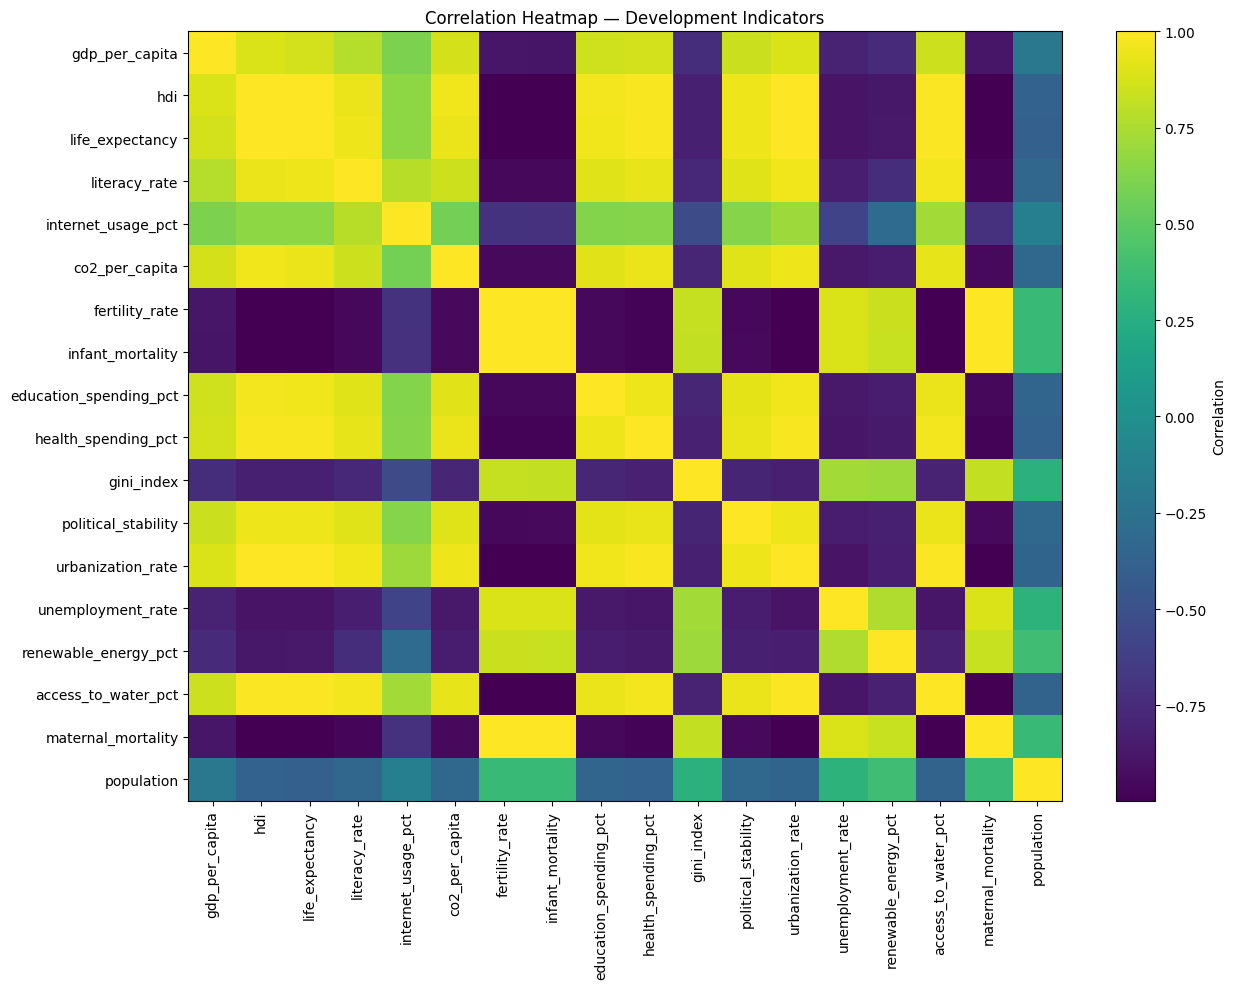

,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,infant_mortality,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
gdp_per_capita,1.00,0.88,0.87,0.78,0.61,0.87,-0.88,-0.88,0.86,0.87,-0.73,0.84,0.88,-0.80,-0.75,0.85,-0.87,-0.20
hdi,0.88,1.00,1.00,0.94,0.66,0.95,-1.00,-1.00,0.96,0.98,-0.82,0.95,1.00,-0.89,-0.87,0.99,-1.00,-0.37
life_expectancy,0.87,1.00,1.00,0.95,0.66,0.94,-0.99,-0.99,0.96,0.98,-0.82,0.95,0.99,-0.89,-0.86,0.99,-0.99,-0.38
literacy_rate,0.78,0.94,0.95,1.00,0.78,0.85,-0.95,-0.96,0.90,0.93,-0.77,0.91,0.95,-0.83,-0.73,0.97,-0.96,-0.34
internet_usage_pct,0.61,0.66,0.66,0.78,1.00,0.58,-0.70,-0.72,0.63,0.64,-0.54,0.64,0.71,-0.59,-0.30,0.73,-0.71,-0.13
co2_per_capita,0.87,0.95,0.94,0.85,0.58,1.00,-0.95,-0.95,0.91,0.94,-0.78,0.90,0.95,-0.86,-0.84,0.93,-0.95,-0.33
fertility_rate,-0.88,-1.00,-0.99,-0.95,-0.70,-0.95,1.00,1.00,-0.96,-0.98,0.82,-0.95,-1.00,0.89,0.84,-0.99,1.00,0.35
infant_mortality,-0.88,-1.00,-0.99,-0.96,-0.72,-0.95,1.00,1.00,-0.96,-0.98,0.82,-0.95,-1.00,0.89,0.83,-0.99,1.00,0.35
education_spending_pct,0.86,0.96,0.96,0.90,0.63,0.91,-0.96,-0.96,1.00,0.95,-0.78,0.92,0.96,-0.86,-0.84,0.95,-0.96,-0.34
health_spending_pct,0.87,0.98,0.98,0.93,0.64,0.94,-0.98,-0.98,0.95,1.00,-0.82,0.94,0.98,-0.88,-0.85,0.97,-0.98,-0.37


In [18]:
corr = df[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(13,10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap — Development Indicators")
save_mpl("correlation_heatmap.png")
display(corr.round(2))

## 5. Build one row per country for non-time-series methods

For clustering, PCA, anomaly detection, association rules, and the country report, year should not duplicate countries. Therefore, all yearly records are averaged into one profile per country. Time series remains separate and keeps all years.

In [19]:
country_profile = df.groupby(["country", "code", "region"], as_index=False)[feature_cols].mean()
print(country_profile.shape)
display(country_profile.head())
save_df(country_profile, "country_average_profile_raw.csv")

(24, 21)


,country,code,region,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,5143.785714,0.503800,72.781429,89.336429,45.450714,1.327429,4.192143,...,5.555786,7.769714,48.761429,0.157707,55.727857,12.152857,44.980000,70.582143,503.871429,3.155758e+08
1,Australia,AUS,Oceania,61492.571429,0.888693,83.382143,99.456429,65.528571,18.231357,1.849071,...,7.693786,12.459571,41.161429,1.828164,85.795714,7.411429,28.705000,97.077143,99.864286,1.102839e+08
2,Brazil,BRA,Americas,8740.550000,0.571457,74.648571,91.860000,47.589286,2.540500,3.757143,...,5.953643,9.007286,47.495714,0.464914,61.052857,11.235714,41.770000,75.321429,436.085714,2.434108e+08
3,China,CHN,Asia,34129.571429,0.689100,78.213571,95.208571,54.845714,3.871000,3.109143,...,6.693429,10.105571,45.721429,1.022550,70.200714,9.788571,36.072857,83.485000,309.814286,1.602121e+08
4,Egypt,EGY,Africa,5080.714286,0.509893,73.010714,89.993571,45.650714,1.384643,4.149714,...,5.494357,7.891357,48.292143,0.134586,56.335000,12.375000,43.107143,71.165714,497.064286,1.786839e+08


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_raw.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_raw.csv')

## 6. Imputation and scaling methods

The app offers multiple scalers. This notebook generates StandardScaler, MinMaxScaler, RobustScaler, and unscaled imputed versions so the professor can see the options.

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, QuantileTransformer

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(country_profile[feature_cols])

scalers = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
    "maxabs": MaxAbsScaler(),
    "quantile_normal": QuantileTransformer(output_distribution="normal", random_state=42, n_quantiles=min(100, len(country_profile)))
}

scaled_versions = {}
for name, scaler in scalers.items():
    temp = country_profile[["country", "code", "region"]].copy()
    temp[feature_cols] = scaler.fit_transform(X_imp)
    scaled_versions[name] = temp
    save_df(temp, f"country_average_profile_{name}_scaled.csv")

standard_df = scaled_versions["standard"]
display(standard_df.head())

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_standard_scaled.csv
Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_minmax_scaled.csv
Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_robust_scaled.csv
Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_maxabs_scaled.csv
Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_quantile_normal_scaled.csv


,country,code,region,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,-0.680392,-0.769929,-0.761701,-0.782048,-0.728753,-0.734670,0.778557,...,-0.699877,-0.811516,0.734854,-0.794367,-0.783603,0.782629,0.851811,-0.799657,0.768045,1.712367
1,Australia,AUS,Oceania,0.824649,1.271747,1.273647,1.337811,1.353579,1.282712,-1.293700,...,1.177521,1.259699,-1.485359,1.194886,1.271431,-1.192503,-1.293823,1.362502,-1.294051,-0.636944
2,Brazil,BRA,Americas,-0.584324,-0.411040,-0.403208,-0.253430,-0.506955,-0.589898,0.393835,...,-0.350515,-0.264959,0.365097,-0.428531,-0.419658,0.400576,0.428617,-0.412901,0.422060,0.886528
3,China,CHN,Asia,0.093800,0.213001,0.281276,0.448003,0.245630,-0.431110,-0.179269,...,0.299098,0.220085,-0.153231,0.235525,0.205566,-0.202259,-0.322473,0.253298,-0.222443,-0.065578
4,Egypt,EGY,Africa,-0.682076,-0.737609,-0.717678,-0.644395,-0.708010,-0.727842,0.741033,...,-0.753818,-0.757794,0.597760,-0.821901,-0.742107,0.875166,0.604900,-0.752033,0.733301,0.145809


## 7. Before/after scaling visual check

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/boxplot_before_scaling.png


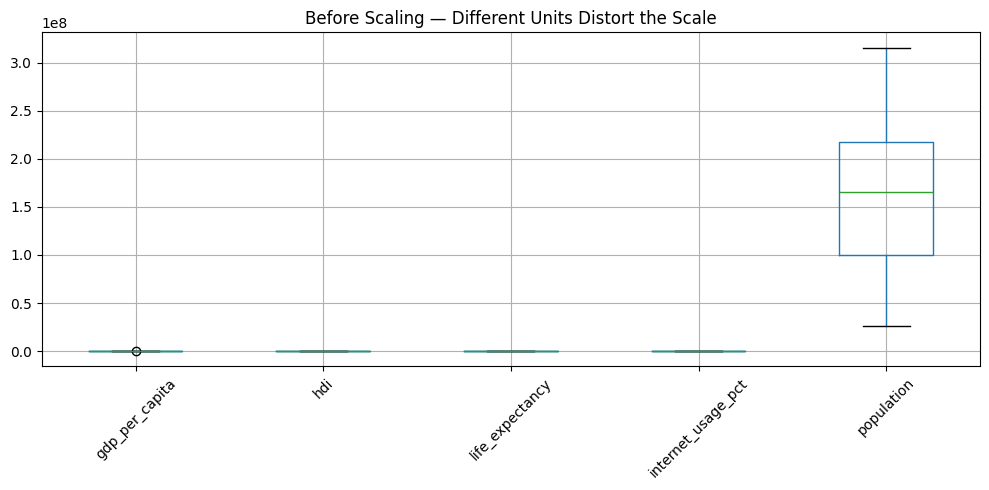

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/boxplot_after_standard_scaling.png


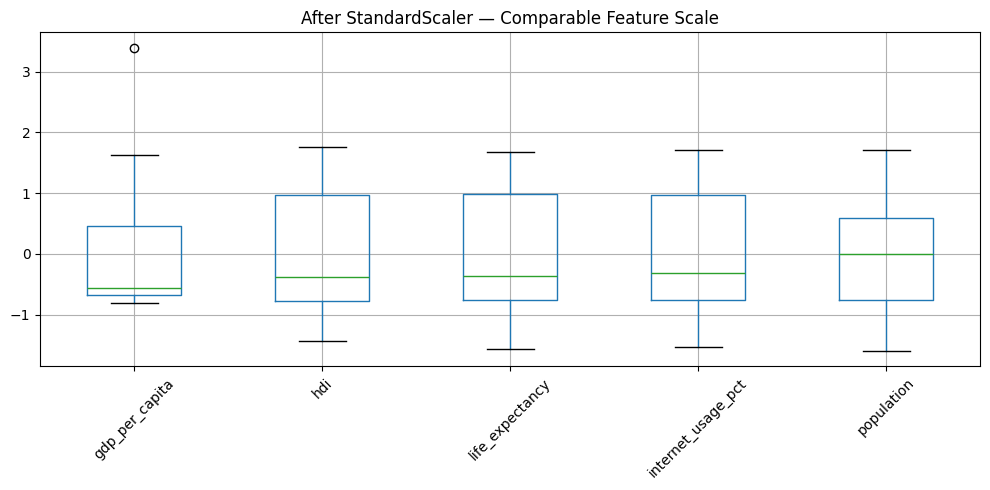

In [21]:
compare_cols = ["gdp_per_capita", "hdi", "life_expectancy", "internet_usage_pct", "population"]
plt.figure(figsize=(10,5))
country_profile[compare_cols].boxplot(rot=45)
plt.title("Before Scaling — Different Units Distort the Scale")
save_mpl("boxplot_before_scaling.png")

plt.figure(figsize=(10,5))
standard_df[compare_cols].boxplot(rot=45)
plt.title("After StandardScaler — Comparable Feature Scale")
save_mpl("boxplot_after_standard_scaling.png")

## 8. Outlier capping option using IQR

This is an optional preprocessing method. It clips extreme values without deleting countries.

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_average_profile_iqr_capped_raw.csv
Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/iqr_capping_gdp_example.png


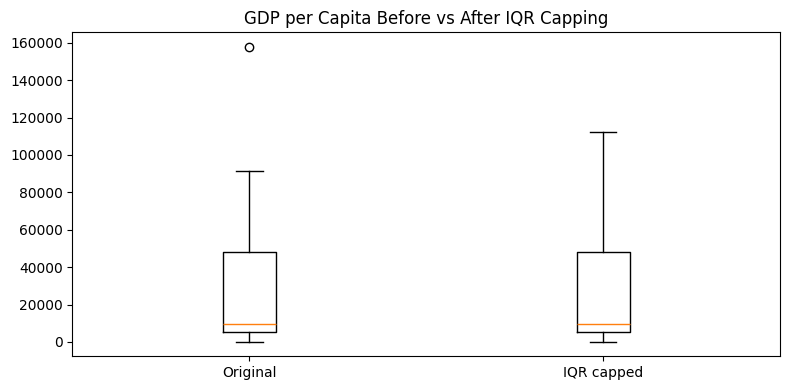

In [22]:
capped = country_profile.copy()
for col in feature_cols:
    q1, q3 = capped[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    capped[col] = capped[col].clip(lower, upper)
save_df(capped, "country_average_profile_iqr_capped_raw.csv")

plt.figure(figsize=(8,4))
plt.boxplot([country_profile["gdp_per_capita"], capped["gdp_per_capita"]], labels=["Original", "IQR capped"])
plt.title("GDP per Capita Before vs After IQR Capping")
save_mpl("iqr_capping_gdp_example.png")

## 9. Final outputs

Use `country_average_profile_standard_scaled.csv` for PCA, clustering, and anomaly detection. Use `world_panel_2010_2023_copy.csv` for time series.

In [23]:
save_df(df, "world_panel_2010_2023_copy.csv")
print("Preprocessing notebook finished successfully.")

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/world_panel_2010_2023_copy.csv
Preprocessing notebook finished successfully.
